Best chromosome: [0 1 0 0 0]
Total weight: 40
Total value: 19


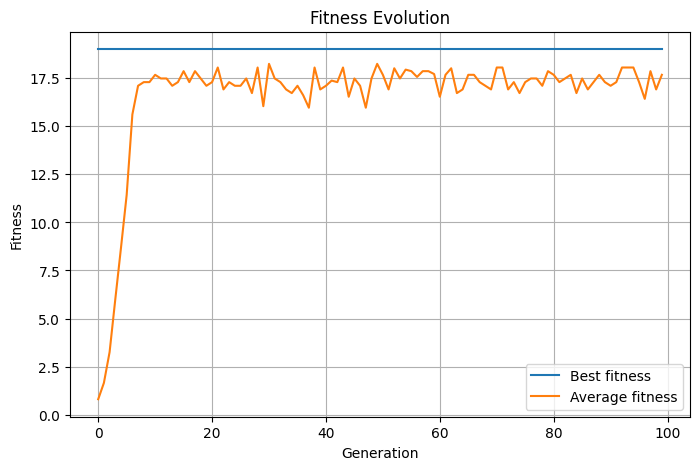

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast

# ---------- Load dataset ---------- #
df = pd.read_csv("knapsack.csv")
first_row = df.iloc[0]
weights = np.array([int(x) for x in first_row['Weights'].strip('[]').split()])
values = np.array([int(x) for x in first_row['Prices'].strip('[]').split()])
capacity = first_row['Capacity']

# ---------- GA parameters ----------
POP_SIZE = 100
GENERATIONS = 100
TOURNAMENT_SIZE = 3
CROSSOVER_PROB = 0.8
MUTATION_PROB = 0.02
ELITISM = True
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------- Helper functions ----------
def fitness(chrom):
    total_w = np.dot(chrom, weights)
    total_v = np.dot(chrom, values)
    if total_w <= capacity:
        return total_v
    else:
        return 0
    
def init_population(pop_size, n):
    return np.random.randint(0, 2, size=(pop_size, n))

def tournament_selection(pop, fitnesses, k):
    selected_idx = []
    pop_size = len(pop)
    for _ in range(pop_size):
        aspirants = np.random.choice(pop_size, size=k, replace=False)
        best = aspirants[np.argmax(fitnesses[aspirants])]
        selected_idx.append(best)
    return pop[selected_idx]

def one_point_crossover(parent1, parent2):
    if len(parent1) <= 1:
        return parent1.copy(), parent2.copy()
    point = random.randint(1, len(parent1) - 1)
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2

def mutate(chrom, pm):
    for i in range(len(chrom)):
        if random.random() < pm:
            chrom[i] = 1 - chrom[i]
    return chrom

# ---------- Main GA loop ----------
population = init_population(POP_SIZE, len(weights))
fitness_history = {'best': [], 'avg': []}
fitnesses = np.array([fitness(ind) for ind in population])

for gen in range(GENERATIONS):
    best_idx = np.argmax(fitnesses)
    best_fit = fitnesses[best_idx]
    avg_fit = np.mean(fitnesses)
    
    fitness_history['best'].append(best_fit)
    fitness_history['avg'].append(avg_fit)

    if ELITISM:
        elite = population[best_idx].copy()
    
    mating_pool = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
    offspring = []
    for i in range(0, POP_SIZE, 2):
        parent1 = mating_pool[i]
        parent2 = mating_pool[(i+1) % POP_SIZE]
        if random.random() < CROSSOVER_PROB:
            c1, c2 = one_point_crossover(parent1, parent2)
        else:
            c1, c2 = parent1.copy(), parent2.copy()
        offspring.append(c1)
        offspring.append(c2)
    offspring = np.array(offspring)

    for i in range(len(offspring)):
        offspring[i] = mutate(offspring[i], MUTATION_PROB)

    population = offspring

    if ELITISM:
        fitnesses_off = np.array([fitness(ind) for ind in population])
        worst_idx = np.argmin(fitnesses_off)
        population[worst_idx] = elite
        fitnesses = np.array([fitness(ind) for ind in population])
    else:
        fitnesses = np.array([fitness(ind) for ind in population])

best_idx = np.argmax(fitnesses)
best_chrom = population[best_idx]
best_weight = int(np.dot(best_chrom, weights))
best_value = int(np.dot(best_chrom, values))

print("Best chromosome:", best_chrom)
print("Total weight:", best_weight)
print("Total value:", best_value)

# ---------- Plot fitness history ----------
plt.figure(figsize=(8,5))
plt.plot(fitness_history['best'], label='Best fitness')
plt.plot(fitness_history['avg'], label='Average fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness Evolution')
plt.legend()
plt.grid(True)
plt.show()